# Long-Horizon Stability on IEEE 118-Bus

This notebook separates two questions that are easy to conflate:

1. **Linear operator stability** — does repeated application of the learned
   Koopman matrix `K` in latent space stay bounded?
2. **End-to-end forecast quality** — does decoded physical RMSE stay low
   over a long open-loop rollout?

It assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) and the IEEE 118 setup from
[`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb); here the focus is how structural
`K` parameterizations affect long open-loop rollouts.

Structural parameterizations (`schur`, `dissipative`, `lyapunov`) **guarantee**
the first property by forcing eigenvalues strictly inside the unit disk
(with a small interior margin). The library's `lyapunov` mode builds a
symmetric $K = Q\operatorname{diag}(d)Q^\top$ with $|d_i|<1$ and an explicit
certificate $P = Q\operatorname{diag}(p)Q^\top$ satisfying
$K^\top P K - P \prec 0$; it is a structured parameterization with a closed-form
$P$, not a solver of the discrete Lyapunov equation for arbitrary dense $K$.
They do **not** automatically guarantee the second: encoder/decoder error and
one-step mismatch still accumulate. This notebook **demonstrates the `lyapunov`
mode** among those structural options (the same unit-disk guarantee applies to
`schur` and `dissipative`).

**Evaluation protocol.** We use a **controlled ablation**: one encoder/decoder
pair is trained end-to-end with dense `K`; a Lyapunov-constrained model then
reuses those weights and retrains **only** `K`. Rollouts are evaluated on a
200-step held-out horizon with ground-truth IEEE 118 snapshots.


## Domain context (for non-experts)

The IEEE 118-bus system is a standard power-grid graph: nodes are buses and edges
are transmission lines. Node features here are bus quantities
`[Vm, Va, Pd, Qd]` (voltage magnitude/angle and active/reactive load). A long
open-loop rollout asks the model to forecast many steps from a single origin
without corrective feedback — the setting where unstable `K` shows up first.


## Method: controlled ablation of `K`

1. Train **dense** `K` end-to-end on the training window.
2. Build a **Lyapunov** model, copy the trained encoder/decoder weights, freeze
   them, and fit **only** the Koopman operator on the same training data.

This isolates the effect of operator parameterization while holding the
lifting and reconstruction maps fixed.


In [1]:
import warnings
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import IEEE118DynamicBenchmark

# Shared IEEE 118 sequence and notebook hyperparameters (defined once here).
MODEL_SEED = 0
DATA_SEED = 42
TRAIN_STEPS = 40
ROLLOUT_STEPS = 50 if os.environ.get("PYTEST_CURRENT_TEST") else 200
TOTAL_STEPS = TRAIN_STEPS + ROLLOUT_STEPS
LATENT_DIM = 32
HIDDEN = 64
TIME_STEP = 0.1
EPOCHS = 15
LR = 1e-3

random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)

full_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=TOTAL_STEPS,
    seed=DATA_SEED,
)
train_sequence = full_sequence.slice(0, TRAIN_STEPS)

in_channels = full_sequence.in_channels
latent_dim = LATENT_DIM
hidden = HIDDEN
time_step = TIME_STEP

print(
    f"Buses: {full_sequence.num_nodes}, features: {in_channels}, "
    f"train={train_sequence.num_timesteps}, holdout={ROLLOUT_STEPS}"
)


Buses: 118, features: 4, train=40, holdout=200


## Helper functions

Notebook-local builders for the ablation and open-loop metrics used below.


In [2]:
def build_model(parameterization: str) -> GraphKoopmanModel:
    torch.manual_seed(MODEL_SEED)
    encoder = GNNEncoder(
        in_channels=in_channels,
        hidden_channels=hidden,
        latent_dim=latent_dim,
    )
    decoder = GNNDecoder(
        latent_dim=latent_dim,
        hidden_channels=hidden,
        out_channels=in_channels,
    )
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=latent_dim,
        time_step=time_step,
        koopman_parameterization=parameterization,
    )


def copy_encoder_decoder(source: GraphKoopmanModel, target: GraphKoopmanModel) -> None:
    target.encoder.load_state_dict(source.encoder.state_dict())
    target.decoder.load_state_dict(source.decoder.state_dict())


def freeze_encoder_decoder(model: GraphKoopmanModel) -> None:
    for param in model.encoder.parameters():
        param.requires_grad = False
    for param in model.decoder.parameters():
        param.requires_grad = False


def rollout_metrics(
    model: GraphKoopmanModel,
    *,
    initial_idx: int,
    steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Return latent norms and decoded RMSE for each open-loop step."""
    model.eval()
    initial = full_sequence[initial_idx]
    edge_index = initial.edge_index
    latent_norms: list[float] = []
    rmse_values: list[float] = []

    with torch.no_grad():
        z = model.encoder(initial, edge_index)
        for step in range(steps):
            z = model.koopman(z)
            pred_x = model.decoder(z, edge_index)
            latent_norms.append(float(z.norm().item()))
            target_x = full_sequence[initial_idx + 1 + step].x
            rmse = torch.sqrt(((pred_x - target_x) ** 2).mean()).item()
            rmse_values.append(rmse)

    return np.asarray(latent_norms), np.asarray(rmse_values)


## Train

Fit the dense baseline end-to-end, then retrain only Lyapunov-constrained `K`
with a frozen encoder/decoder copy. The IEEE 118 sequence above uses
**40** training snapshots and **200** held-out steps (shorter under pytest);
rollout starts from the final training snapshot.


In [3]:
dense_model = build_model("dense")
dense_model.fit(train_sequence, epochs=EPOCHS, lr=LR)

stable_model = build_model("lyapunov")
copy_encoder_decoder(dense_model, stable_model)
freeze_encoder_decoder(stable_model)
stable_model.fit(train_sequence, epochs=EPOCHS, lr=LR)

cert = stable_model.koopman.stability_certificate()
print("Lyapunov margin:", float(cert.margin.detach()))
print("Lyapunov bound_metric:", float(stable_model.koopman.bound_metric().detach()))
print("Lyapunov spectral radius (true):", float(stable_model.koopman.spectral_radius().detach()))
print("Dense spectral radius (true):", float(dense_model.koopman.spectral_radius().detach()))


Lyapunov margin: 0.00010097026824951172
Lyapunov bound_metric: 0.9998990297317505
Lyapunov spectral radius (true): 0.9999000430107117
Dense spectral radius (true): 1.114484190940857


## Evaluate on the held-out rollout

Both metrics are reported on **every** rollout step against held-out ground
truth:

- **Decoded RMSE** — physical-space error after the GNN decoder (forecast quality).
- **Latent norm** — `‖z‖₂` after each linear `K` step (operator stability proxy).

A structurally stable `K` should keep latent norms bounded. Decoded RMSE can
still grow if the encoder/decoder do not perfectly represent the dynamics.
The left panel uses a **log** RMSE scale so the Lyapunov curve stays readable
next to dense blow-up.


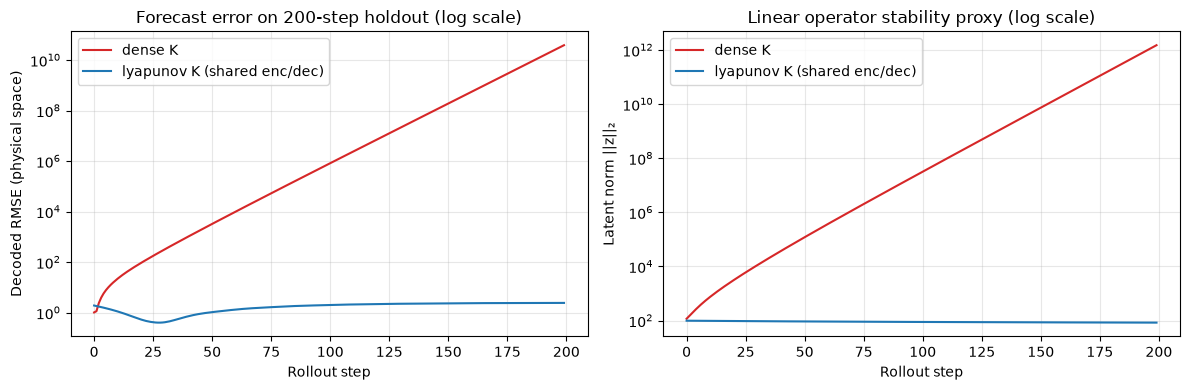

Final decoded RMSE — dense: 38644297728.0000, lyapunov: 2.4332
Final latent norm — dense: 1503797575680.0000, lyapunov: 83.8206
Mean decoded RMSE (last 50 steps) — dense: 7489063828.4800, lyapunov: 2.3977


In [4]:
initial_idx = TRAIN_STEPS - 1
dense_latent, dense_rmse = rollout_metrics(
    dense_model,
    initial_idx=initial_idx,
    steps=ROLLOUT_STEPS,
)
stable_latent, stable_rmse = rollout_metrics(
    stable_model,
    initial_idx=initial_idx,
    steps=ROLLOUT_STEPS,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(dense_rmse, label="dense K", color="tab:red")
axes[0].plot(stable_rmse, label="lyapunov K (shared enc/dec)", color="tab:blue")
axes[0].set_xlabel("Rollout step")
axes[0].set_ylabel("Decoded RMSE (physical space)")
axes[0].set_yscale("log")
axes[0].set_title(f"Forecast error on {ROLLOUT_STEPS}-step holdout (log scale)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, which="both")

axes[1].plot(dense_latent, label="dense K", color="tab:red")
axes[1].plot(stable_latent, label="lyapunov K (shared enc/dec)", color="tab:blue")
axes[1].set_xlabel("Rollout step")
axes[1].set_ylabel("Latent norm ||z||₂")
axes[1].set_yscale("log")
axes[1].set_title("Linear operator stability proxy (log scale)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"Final decoded RMSE — dense: {dense_rmse[-1]:.4f}, lyapunov: {stable_rmse[-1]:.4f}")
print(f"Final latent norm — dense: {dense_latent[-1]:.4f}, lyapunov: {stable_latent[-1]:.4f}")
print(
    f"Mean decoded RMSE (last 50 steps) — dense: {dense_rmse[-50:].mean():.4f}, "
    f"lyapunov: {stable_rmse[-50:].mean():.4f}"
)


## Takeaways

- **What structural parameterizations guarantee:** Eigenvalues of `K` stay
  strictly inside the unit disk, so repeated *linear* latent propagation
  cannot blow up exponentially. Inspect `model.koopman.stability_certificate()`
  and `bound_metric()` (closed-form) / `spectral_radius()` (true eigvals) to
  verify this. Here we train the **`lyapunov`** structural mode; `schur` and
  `dissipative` share the same unit-disk guarantee.
- **What they do *not* guarantee:** Low decoded RMSE on long horizons. That
  depends on encoder/decoder quality and one-step model error, which still
  compounds during open-loop rollout even when `‖z‖₂` is bounded.
- **Claim supported here:** Shared encoder/decoder isolate the effect of `K`;
  the 200-step holdout supplies ground-truth physical targets for every
  rollout step. Interpret the left panel as **forecast quality** and the right
  panel as **operator stability** — related, but not the same claim.
- **Soft regularization contrast:** For soft spectral penalties (including ODO
  `bound_metric()` monitoring), see
  [`08_loss_stability.ipynb`](08_loss_stability.ipynb). This notebook
  demonstrates **hard** structural constraints only, not a head-to-head
  benchmark against those methods.

## Next steps

- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for the base IEEE 118 forecasting tutorial.
- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) for soft spectral regularization.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) for eigenvalue diagnostics.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
